# 데이터 출처

- 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 소성가공 자원최적화 AI 데이터셋,
- KAIST(울산과학기술원, ㈜리쉐니에), 2022.12.23., www.kamp-ai.kr

# 1. Data Loading 및 기본 조회

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from datetime import datetime

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

<Figure size 1000x800 with 0 Axes>

In [2]:
org_df = pd.read_csv('./data/okm_augumented_2021.csv')

org_df.head(20)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [5]:

org_df.tail()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


- 9월 14일까지만 데이터 존재

In [6]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


In [4]:
org_df[['m','전기요금(계절)']].groupby('m').value_counts()

m  전기요금(계절)
1  109.8       744
2  109.8       672
3  167.2       744
4  167.2       720
5  167.2       744
6  191.6       720
7  191.6       744
8  191.6       744
9  167.2       336
Name: count, dtype: int64

## 1.1 전기요금 구조
- 겨울 : 109.8원, 여름 : 191.6원, 봄/가을 : 167.2원 (kwh 당)
- 시간대별로 구분없이 계절별 단일 요금제 사용

## 1.2 본 노트북 목적
- 전기요금 산정의 기초가 되는 전력 사용량이 없음
- 시간 별 최대전력값을 기초로 생산량, 인력 정보를 활용하여 생산 제품 또는 공정을 구분하고 그에 적합한 전력사용량 산정 방안 도출

# 2. Data Cleansing & Review - 이상치 확인 및 데이터 확인

* Data 전처리 및 Cleansing을 위한 사본 저장

In [4]:
power_df = org_df.copy()

## 2.1 결측치 확인 및 정리

### 결측치 조사

In [9]:
org_df.isna().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

* 결측치 - 강수량 1건, 공장인원 17건

### 결측치 조치
* 0 으로 설정

In [5]:
power_df['강수량'] = org_df['강수량'].fillna(0)
power_df['공장인원'] = org_df['공장인원'].fillna(0)

power_df.isna().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          3
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

## 2.2 이상치 확인 및 정정

### 데이터 통계 요약 
* 평균, 분산, 표준편차, 1/4, 2/4, 3/4 분위
* 상관관계 : corr()

In [11]:
power_df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6165.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.063633,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164118,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


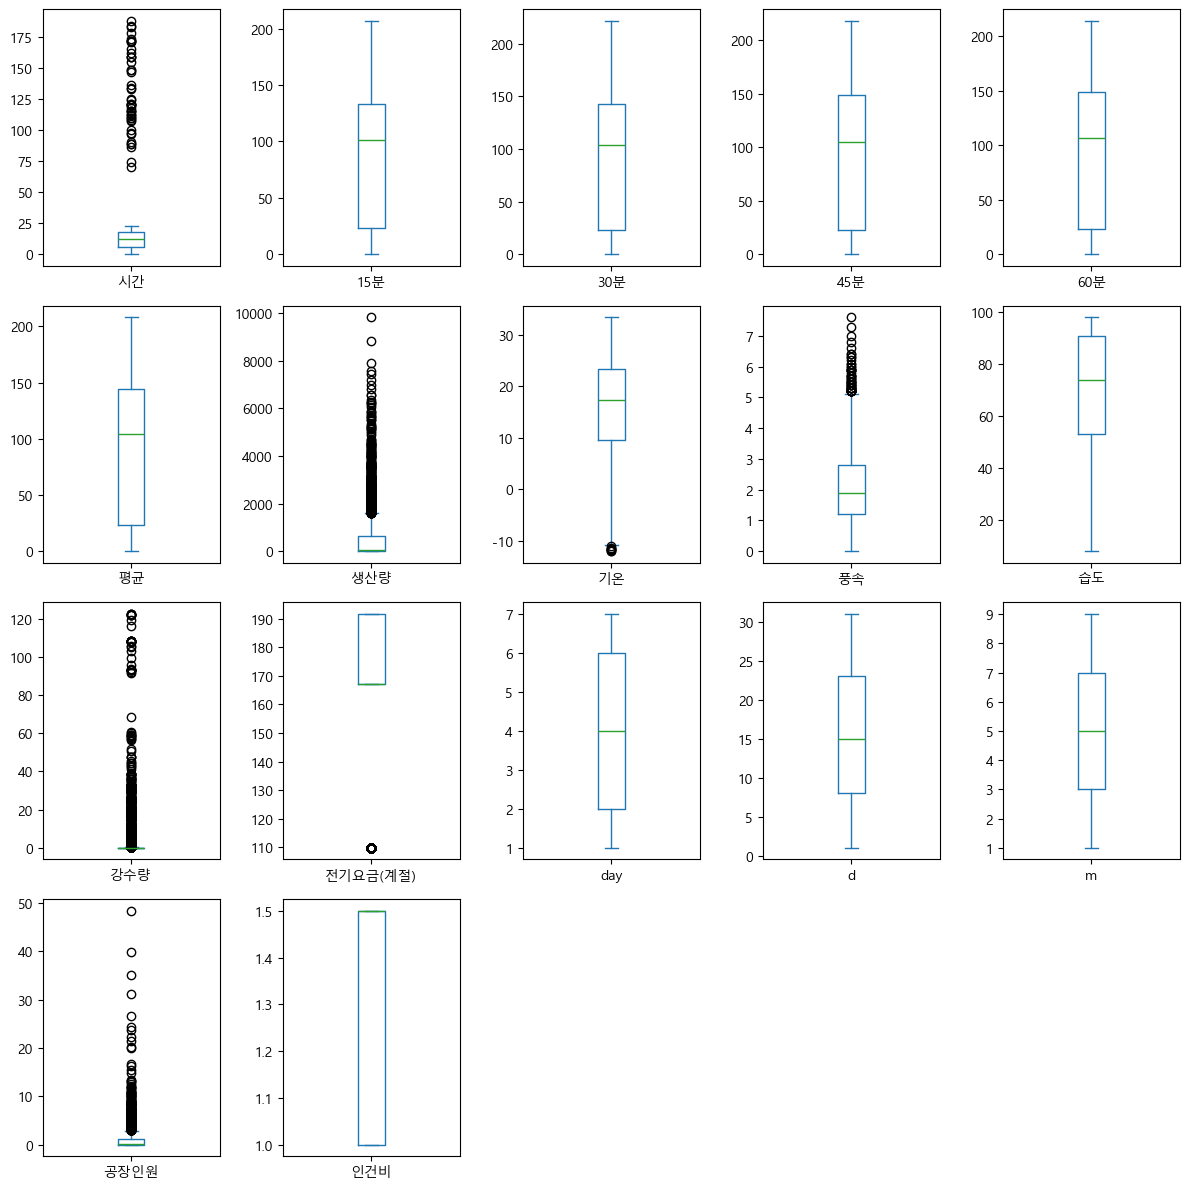

In [12]:
# 일자는 제외
# sns.boxplot(data=power_df.drop(columns=['날짜', '생산량']))
# plt.title('Seaborn Boxplot')

# 한 줄에 5개씩 배치 (열 개수에 맞춰 행 수는 자동 계산)
df = power_df.drop(columns=['날짜'])
df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

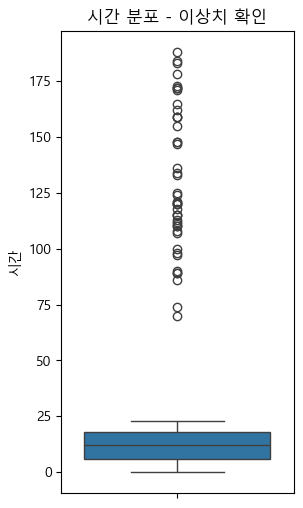

In [13]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

### 시간 정보가 잘못됨

In [14]:
power_df['시간'].unique(), len(power_df['시간'].unique())

# print(len(power_df['시간'].unique()))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  70,  89,
         90,  97, 107, 108, 112, 113, 115, 118, 120, 121, 124, 133, 136,
        148, 155, 159, 165, 171, 172, 188,  74,  86,  98, 100, 110, 111,
        125, 134, 147, 162, 173, 178, 183, 184]),
 60)

In [6]:
# 시간 정보 오류 확인 및 수정

err_df = power_df[(power_df['시간'] < 0) | (power_df['시간'] > 23)].copy()

err_df
# err_df.count()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
4632,20210713,70,70,69,69,69,69,0,25.1,2.0,98,0.0,191.6,2,13,7,0.0,1.5
4633,20210713,89,77,93,119,94,96,0,25.0,1.3,97,0.0,191.6,2,13,7,0.0,1.5
4634,20210713,90,117,110,114,107,112,0,24.9,1.5,96,0.0,191.6,2,13,7,0.0,1.5
4635,20210713,97,115,107,112,107,110,0,24.7,0.4,96,0.0,191.6,2,13,7,0.0,1.5
4636,20210713,107,106,112,101,106,106,0,24.5,1.4,96,0.0,191.6,2,13,7,0.0,1.5
4637,20210713,108,121,153,162,136,143,0,24.7,0.2,96,0.0,191.6,2,13,7,0.0,1.5
4638,20210713,112,125,124,121,120,123,0,25.8,1.0,93,0.0,191.6,2,13,7,0.0,1.5
4639,20210713,113,112,107,113,111,111,0,27.5,1.0,84,0.0,191.6,2,13,7,0.0,1.5
4640,20210713,115,112,110,81,104,102,0,29.2,1.9,73,0.0,191.6,2,13,7,0.0,1.5
4641,20210713,118,105,118,112,113,112,0,29.3,3.0,69,0.0,191.6,2,13,7,0.0,1.5


In [16]:
err_df['날짜'].value_counts()

날짜
20210713    24
20210715    24
Name: count, dtype: int64

###  날짜 오류 수정을 위한 데이타 확인 및 테스트

In [67]:
err_df['날짜'].unique().tolist()

[20210713, 20210715]

In [7]:
for date in err_df['날짜'].unique().tolist() :
    err_df.loc[err_df['날짜'] == date, '시간'] = np.arange(24)

err_df[['날짜', '시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


###  날짜 오류 수정 반영

In [8]:
err_dates = err_df['날짜'].unique().tolist()
for date in err_df['날짜'].unique().tolist() :
    power_df.loc[power_df['날짜'] == date, '시간'] = np.arange(24)

power_df.loc[power_df['날짜'].isin(err_dates), ['날짜','시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


In [18]:
power_df['시간'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

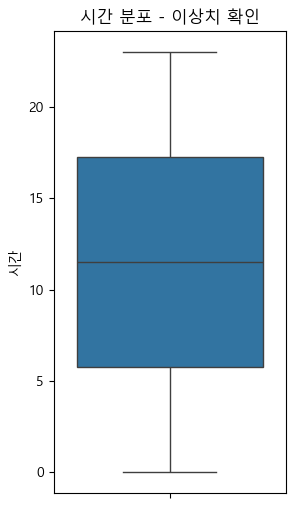

In [20]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

## 컬럼명 변경

In [9]:
power_df.rename(columns={'day': '요일', 'd': '일자', 'm': '월'}, inplace=True)
power_df.rename(columns={'평균': '최대전력평균', '인건비': '인건비할증'}, inplace=True)
power_df

,날짜,시간,15분,30분,45분,60분,최대전력평균,생산량,기온,풍속,습도,강수량,전기요금(계절),요일,일자,월,공장인원,인건비할증
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


# 3. 생산, 전력 사용 관련 데이터 상관관계 조사 

## 3.1 생산량과 인건비 상관관계 확인

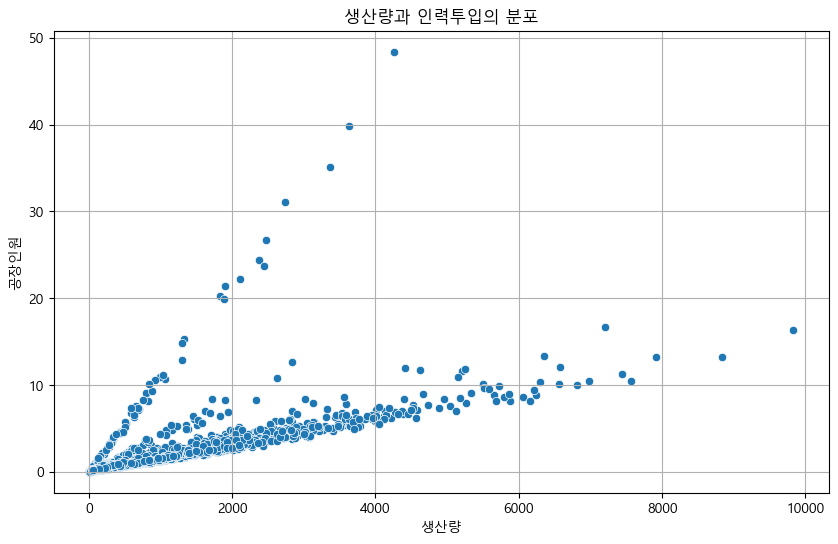

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=power_df, x='생산량', y='공장인원')

plt.title('생산량과 인력투입의 분포')
plt.grid(True)
plt.show()


인력과 생산량 관계에 따라 3개의 그룹으로 분류 

### 3.1.1 비지도 군집화  - GaussianMixture 이용
- 선형적 상관관계가 있는 그룹들을 묶기 위해 기울기를 기준으로 그룹화

In [12]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

# 1. 데이터 분리 및 분석용 기울기 계산
mask_zero = power_df['생산량'] <= 0
df_na = power_df[mask_zero].copy()

# 생산량이 없는 경우 0로 사전 분류
df_na['생산구분'] = 0 

df_target = power_df[~mask_zero].copy()
# '생산인력비율' 계산 (제품 1000개당 투입 인원) : 적정한 크기의 숫자로 변환
df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 1000)

# 2. GMM 분류 및 초기 라벨링 (4, 2, 1)
X_ratio = df_target[['생산인력비율']].values

# 2.2 로그 변환 (Log Transformation)
# 비율 데이터의 이분산성을 줄여 하단 그룹 간의 '거리'를 확보합니다.
# np.log1p는 log(1+x)로, 혹시 모를 0값에 대한 오류를 방지합니다.
X_log = np.log1p(X_ratio)
  
# 3. GMM 모델 생성 및 학습
# 1차원 데이터이므로 covariance_type은 기본값('full')을 유지해도 무방합니다.
gmm = GaussianMixture(
    n_components=3, 
    n_init=20, 
    covariance_type='full', 
    random_state=42
)

gmm = GaussianMixture(n_components=3, n_init=20, random_state=42)
df_target['cluster'] = gmm.fit_predict(X_log) + 1 # 1부터 시작하도록 조정

# 4. 결과 매핑 (기울기 평균이 높은 순서대로 4, 2, 1 부여)
# 로그 변환된 값이 아닌 원본 '생산인력비율'의 평균으로 그룹 순서를 결정합니다.
cluster_avg = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False)
    
# label_map 생성: 가장 높은 비율 그룹(4), 중간(2), 가장 낮은 비율 그룹(1)
label_map = {
    cluster_avg.index[0]: 4, 
    cluster_avg.index[1]: 2, 
    cluster_avg.index[2]: 1
    }
df_target['생산구분'] = df_target['cluster'].map(label_map)

# 재분류 전 그룹별 사이즈
print(df_target['생산구분'].value_counts())
print(df_target['cluster'].value_counts())

# [출력 1] 재분류 전 통계 (순수 GMM 결과)
print("\n" + "="*50)
print("[1. 재분류 전 통계 (Pure GMM + Log Trans)]")
before_stats = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', lambda x: x.quantile(0.75)]).rename(columns={'<lambda_0>': '3Q'})
print(before_stats)

# 4. [정밀 재분류] 중간(2) 그룹의 75% 지점 * 1.15 적용
middle_q3 = df_target.loc[df_target['생산구분'] == 2, '생산인력비율'].quantile(0.75)
threshold = middle_q3 * 1.15
reassign_mask = (df_target['생산구분'] == 2) & (df_target['생산인력비율'] <= threshold)
df_target.loc[reassign_mask, '생산구분'] = 1

# 4. 결과 통합 및 데이터프레임 정리
# (1) power_df: 기존 모든 컬럼 유지 + '생산구분'만 추가
# 모든 행의 라벨을 하나로 합친 뒤, 원본 power_df에 인덱스 기준으로 붙입니다.
all_labels = pd.concat([df_target[['생산구분']], df_na[['생산구분']]]).sort_index()
power_df['생산구분'] = all_labels['생산구분']

# (2) product_df: 요청하신 5개 컬럼만 추출
product_df = df_target[['생산량', '공장인원', '생산인력비율', 'cluster', '생산구분', '최대전력평균']].copy()

# print("분류 및 데이터 통합 완료!")
# print(f"power_df 컬럼 목록: {power_df.columns.tolist()}")
# print(f"product_df 컬럼 목록: {product_df.columns.tolist()}")

print("-"*80)
print("재분류 후 데이터 분포")
print(df_target['생산구분'].value_counts())
# [출력 2] 재분류 후 통계
print("\n" + "="*50)
print(f"[2. 재분류 후 통계 (Threshold: {threshold:.4f} 적용)]")
after_stats = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', lambda x: x.quantile(0.75)]).rename(columns={'<lambda_0>': '3Q'})
print(after_stats)
print("="*50)


생산구분
2    2096
1    1318
4      97
Name: count, dtype: int64
cluster
1    2096
3    1318
2      97
Name: count, dtype: int64

[1. 재분류 전 통계 (Pure GMM + Log Trans)]
           mean         3Q
생산구분                      
1      1.500687   1.577287
2      2.356489   2.481390
4     10.936385  11.363636
--------------------------------------------------------------------------------
재분류 후 데이터 분포
생산구분
1    3232
2     182
4      97
Name: count, dtype: int64

[2. 재분류 후 통계 (Threshold: 2.8536 적용)]
           mean         3Q
생산구분                      
1      1.936538   2.320186
2      3.616573   3.964333
4     10.936385  11.363636


In [17]:
power_df

,날짜,시간,15분,30분,45분,60분,최대전력평균,생산량,기온,풍속,습도,강수량,전기요금(계절),요일,일자,월,공장인원,인건비할증,생산구분
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5,0
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5,0
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5,0
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5,0
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5,1
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5,1
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5,1
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5,1


* product_df 는 생산량이 0 보다 큰 데이터 집합

In [18]:
product_df.info() 
product_df

<class 'pandas.DataFrame'>
Index: 3511 entries, 80 to 6167
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   생산량      3511 non-null   int64  
 1   공장인원     3511 non-null   float64
 2   생산인력비율   3511 non-null   float64
 3   cluster  3511 non-null   int64  
 4   생산구분     3511 non-null   int64  
 5   최대전력평균   3511 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 192.0 KB


,생산량,공장인원,생산인력비율,cluster,생산구분,최대전력평균
80,165,0.264000,1.600000,3,1,156
81,313,0.488300,1.560062,3,1,160
82,2757,4.404153,1.597444,3,1,157
83,983,1.652101,1.680672,3,1,149
84,96,0.268908,2.801120,1,1,89
...,...,...,...,...,...,...
6163,1497,2.442088,1.631321,3,1,153
6164,45,0.087891,1.953125,1,1,128
6165,149,0.290448,1.949318,1,1,128
6166,66,0.148984,2.257336,1,1,111


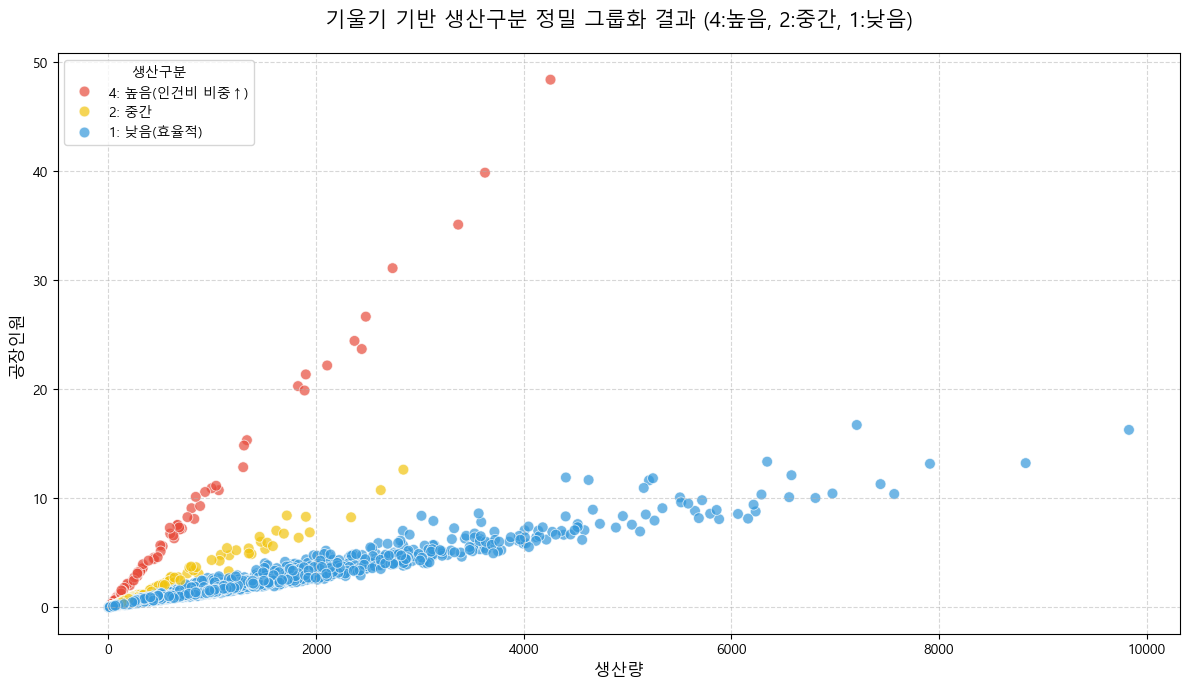

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 데이터 준비 (N/A인 -1 제외)
# product_df 이용

# # 2. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
# plt.rc('font', family='Malgun Gothic') 
# plt.rcParams['axes.unicode_minus'] = False

# 3. 산점도 시각화
plt.figure(figsize=(12, 7))

# 숫자 라벨에 따른 색상 및 순서 지정 (4:높음, 2:중간, 1:낮음)
palette = {4: '#e74c3c', 2: '#f1c40f', 1: '#3498db'}
hue_order = [4, 2, 1]

sns.scatterplot(
    data=product_df, 
    x='생산량', 
    y='공장인원', 
    hue='생산구분', 
    hue_order=hue_order,
    palette=palette,
    alpha=0.7,
    edgecolor='w',
    s=60
)

# 4. 그래프 꾸미기 (범례 텍스트 커스텀)
plt.title('기울기 기반 생산구분 정밀 그룹화 결과 (4:높음, 2:중간, 1:낮음)', fontsize=15, pad=20)
plt.xlabel('생산량', fontsize=12)
plt.ylabel('공장인원', fontsize=12)

# 범례에 숫자와 의미를 명시적으로 표시
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['4: 높음(인건비 비중↑)', '2: 중간', '1: 낮음(효율적)'], 
           title='생산구분', loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [91]:
power_df['생산량'].max()

np.int64(9830)

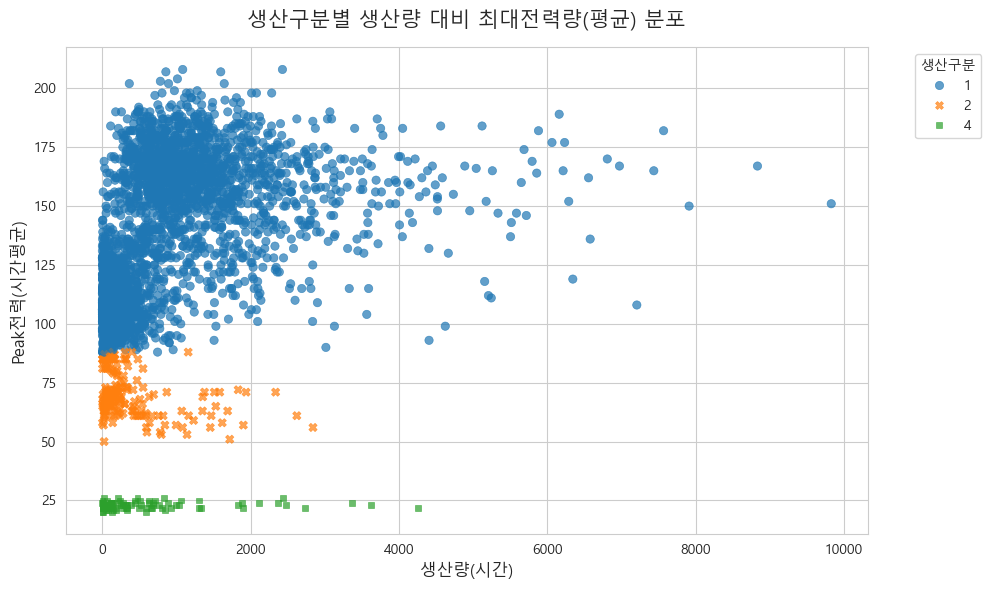

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 필터링 및 설정값 정의
categories = [1, 2, 4]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 요청하신 파랑, 주황, 초록
target_df = product_df[product_df['생산구분'].isin(categories)]

# 3. 산포도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=target_df, 
    x='생산량', 
    y='최대전력평균', 
    hue='생산구분', 
    palette=colors,      # 정의한 색상 리스트 적용
    hue_order=categories, # 색상 순서 고정
    style='생산구분', 
    alpha=0.7, 
    edgecolor=None
)

# 4. 타이틀 및 라벨 설정
plt.title('생산구분별 생산량 대비 최대전력량(평균) 분포', fontsize=15, pad=15)
plt.xlabel('생산량(시간)', fontsize=12)
plt.ylabel('Peak전력(시간평균)', fontsize=12)
plt.legend(title='생산구분', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


** 최대전력을 포함시 : 파란색 그룹이 두개의 서브그룹으로 나누어 질수 있을 듯함 

## 3.2 생산량, 인건비, 최대전력 상관관계 확인 
- 최대전력평균을 추가하여 재분류

In [13]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. 데이터 분리
mask_zero = power_df['생산량'] <= 0
df_na = power_df[mask_zero].copy()
df_na['생산구분'] = 0
df_target = power_df[~mask_zero].copy()

# 생산인력비율 계산
df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 1000)

# 2. GMM 분류를 위한 전처리 (생산인력비율, 최대전력평균)
# 두 변수의 스케일 차이가 클 수 있으므로 로그 변환 후 표준화(Scaling)를 진행합니다.
X_features = df_target[['생산인력비율', '최대전력평균']].copy()

# 로그 변환 (비대칭성 해소)
X_log = np.log1p(X_features)

# 표준화 (두 변수의 영향력을 동일하게 맞춤)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 3. GMM 모델 생성 및 학습 (n_components=4)
gmm = GaussianMixture(
    n_components=4, 
    n_init=20, 
    random_state=42
)
df_target['cluster'] = gmm.fit_predict(X_scaled) + 1

# 4. 결과 매핑 (생산인력비율 평균이 높은 순서대로 4, 3, 2, 1 부여)
# 그룹의 성격을 규정하는 기준에 따라 정렬 순서는 변경 가능합니다.
cluster_order = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False).index

label_map = {
    cluster_order[0]: 4,
    cluster_order[1]: 3,
    cluster_order[2]: 2,
    cluster_order[3]: 1
}
df_target['생산구분'] = df_target['cluster'].map(label_map)

# 5. 결과 통합
all_labels = pd.concat([df_target[['생산구분']], df_na[['생산구분']]]).sort_index()
power_df['생산구분'] = all_labels['생산구분']

# product_df 추출
product_df = df_target[['생산량', '공장인원', '생산인력비율', '최대전력평균', 'cluster', '생산구분']].copy()

# 출력: 결과 확인
print("="*50)
print("[GMM 4개 그룹 분류 통계]")
stats = df_target.groupby('생산구분')[['생산인력비율', '최대전력평균']].agg(['mean', 'count'])
print(stats)
print("="*50)


[GMM 4개 그룹 분류 통계]
         생산인력비율            최대전력평균      
           mean count        mean count
생산구분                                   
1      1.529273  1495  164.721739  1495
2      2.278233  1706  110.998828  1706
3      3.493794   213   73.521127   213
4     10.936385    97   23.020619    97


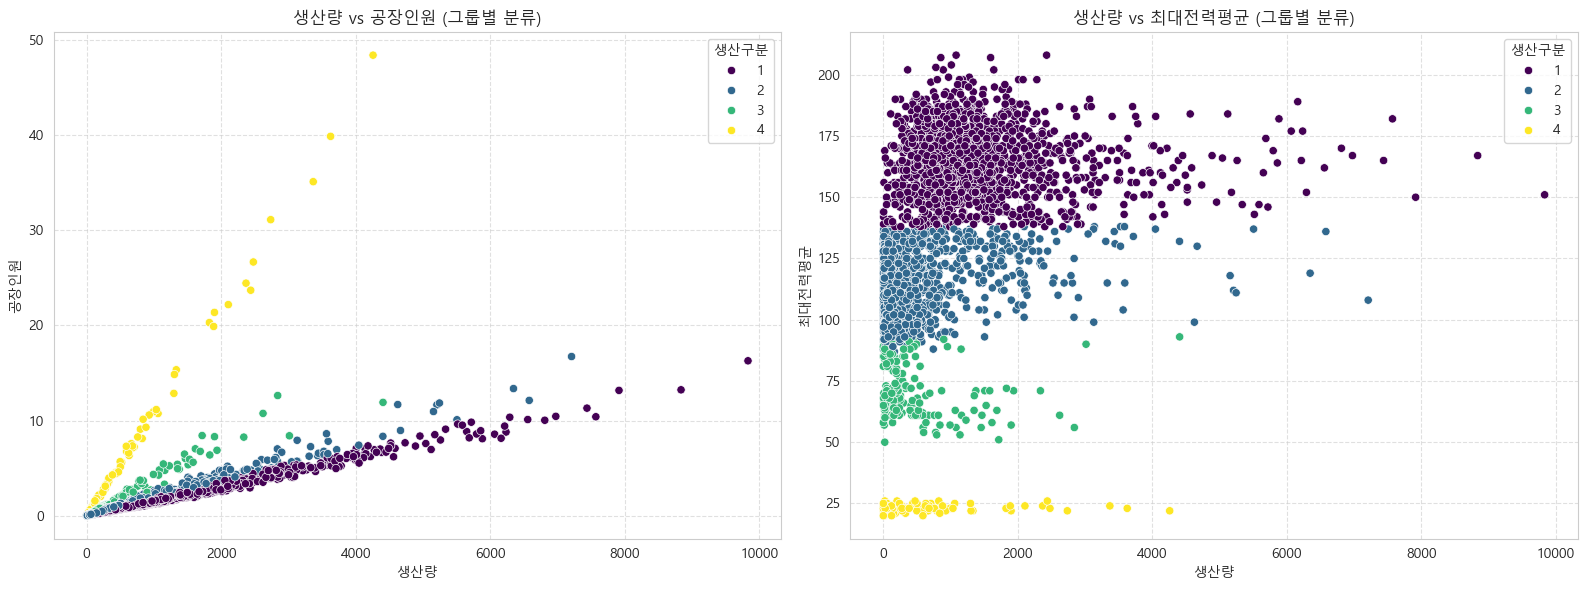

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

# 시각화 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 생산량 - 공장인원 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='공장인원', 
    hue='생산구분', 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('생산량 vs 공장인원 (그룹별 분류)')
axes[0].set_xlabel('생산량')
axes[0].set_ylabel('공장인원')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. 생산량 - 최대전력평균 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='최대전력평균', 
    hue='생산구분', 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('생산량 vs 최대전력평균 (그룹별 분류)')
axes[1].set_xlabel('생산량')
axes[1].set_ylabel('최대전력평균')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\3376484878.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_6612\3376484878.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


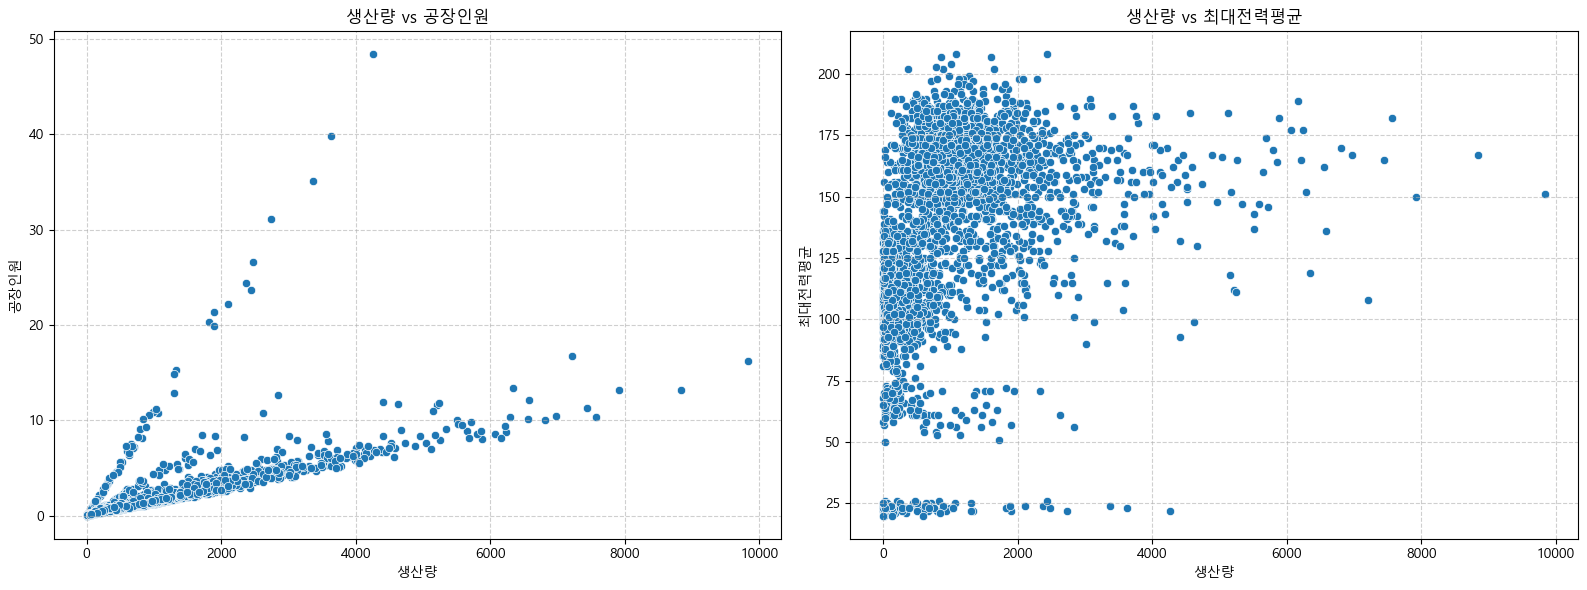

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

# 시각화 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 생산량 - 공장인원 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='공장인원', 
    # hue='생산구분', 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('생산량 vs 공장인원')
axes[0].set_xlabel('생산량')
axes[0].set_ylabel('공장인원')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. 생산량 - 최대전력평균 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='최대전력평균', 
    # hue='생산구분', 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('생산량 vs 최대전력평균')
axes[1].set_xlabel('생산량')
axes[1].set_ylabel('최대전력평균')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### 데이터 하나만 타겟으로 변경 그룹 3 중, 생산량이 4,000 이상인 것을 2그룹으로 변경

In [14]:
# df_target에서 조건에 맞는 행의 '생산구분'을 2로 변경
df_target.loc[(df_target['생산구분'] == 3) & (df_target['생산량'] > 4000), '생산구분'] = 2

# (선택사항) 변경된 내용을 원본 power_df에도 반영하려면 아래 코드를 실행하세요.
power_df.loc[df_target.index, '생산구분'] = df_target['생산구분']

# 변경 확인
print(f"변경 후 그룹 2의 데이터 개수: {len(df_target[df_target['생산구분'] == 2])}개")


변경 후 그룹 2의 데이터 개수: 1707개


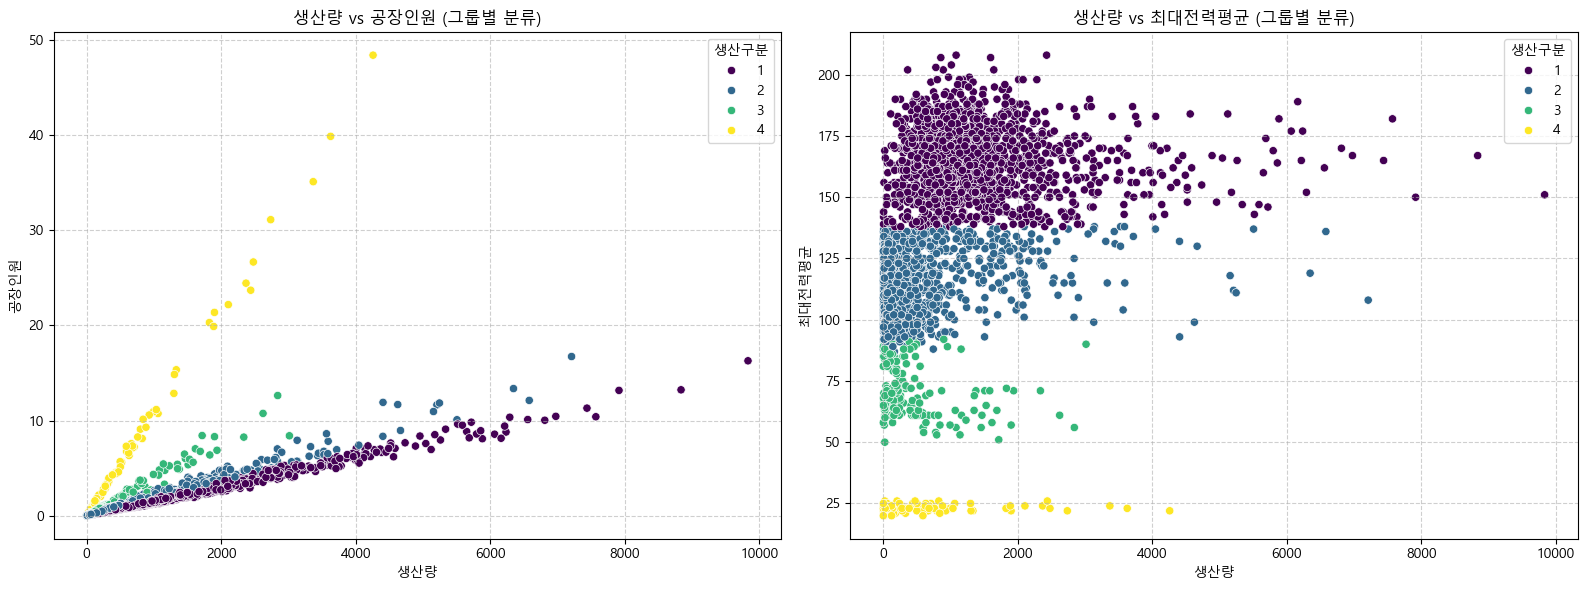

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

# 시각화 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 생산량 - 공장인원 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='공장인원', 
    hue='생산구분', 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('생산량 vs 공장인원 (그룹별 분류)')
axes[0].set_xlabel('생산량')
axes[0].set_ylabel('공장인원')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. 생산량 - 최대전력평균 산포도
sns.scatterplot(
    data=df_target, 
    x='생산량', 
    y='최대전력평균', 
    hue='생산구분', 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('생산량 vs 최대전력평균 (그룹별 분류)')
axes[1].set_xlabel('생산량')
axes[1].set_ylabel('최대전력평균')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

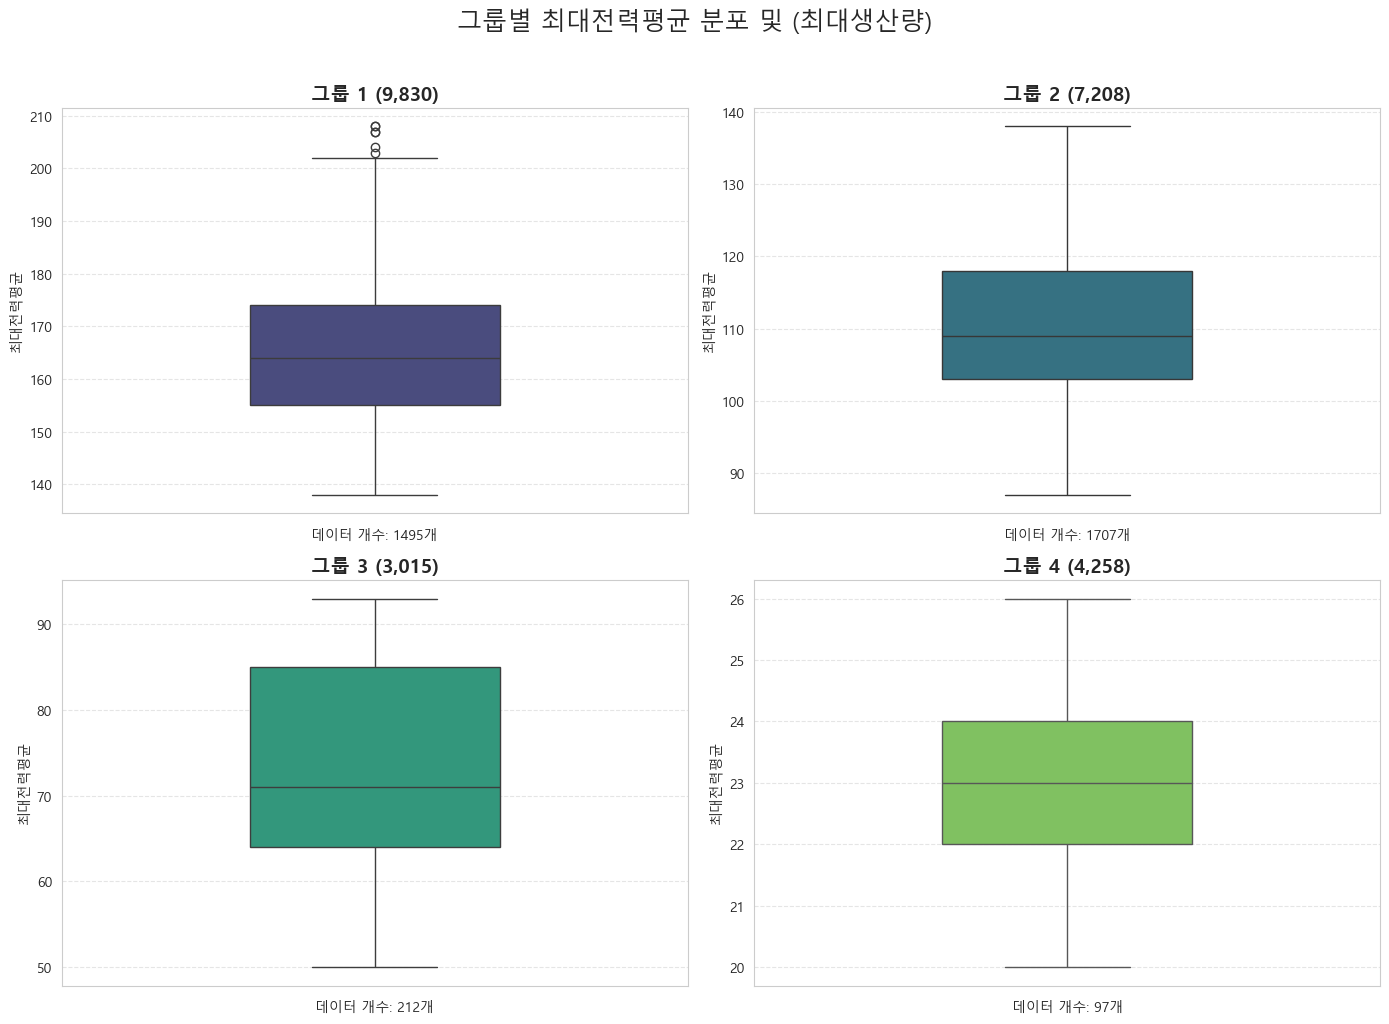

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 각 생산구분(1, 2, 3, 4)별로 순회하며 시각화
for i, label in enumerate(sorted(df_target['생산구분'].unique())):
    # 해당 그룹 데이터 추출
    group_data = df_target[df_target['생산구분'] == label]
    
    # 해당 그룹의 최대생산량 계산
    max_prod = group_data['생산량'].max()
    
    # 박스플롯 그리기
    sns.boxplot(
        data=group_data, 
        y='최대전력평균', 
        ax=axes[i], 
        color=sns.color_palette("viridis", 4)[i],
        width=0.4
    )
    
    # 타이틀 설정: 그룹명 + (최대생산량)
    # 숫자가 클 경우 읽기 편하도록 천 단위 콤마(,) 추가
    axes[i].set_title(f'그룹 {int(label)} ({max_prod:,.0f})', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('최대전력평균')
    axes[i].set_xlabel(f'데이터 개수: {len(group_data)}개')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 전체 레이아웃 조정
plt.suptitle('그룹별 최대전력평균 분포 및 (최대생산량)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()



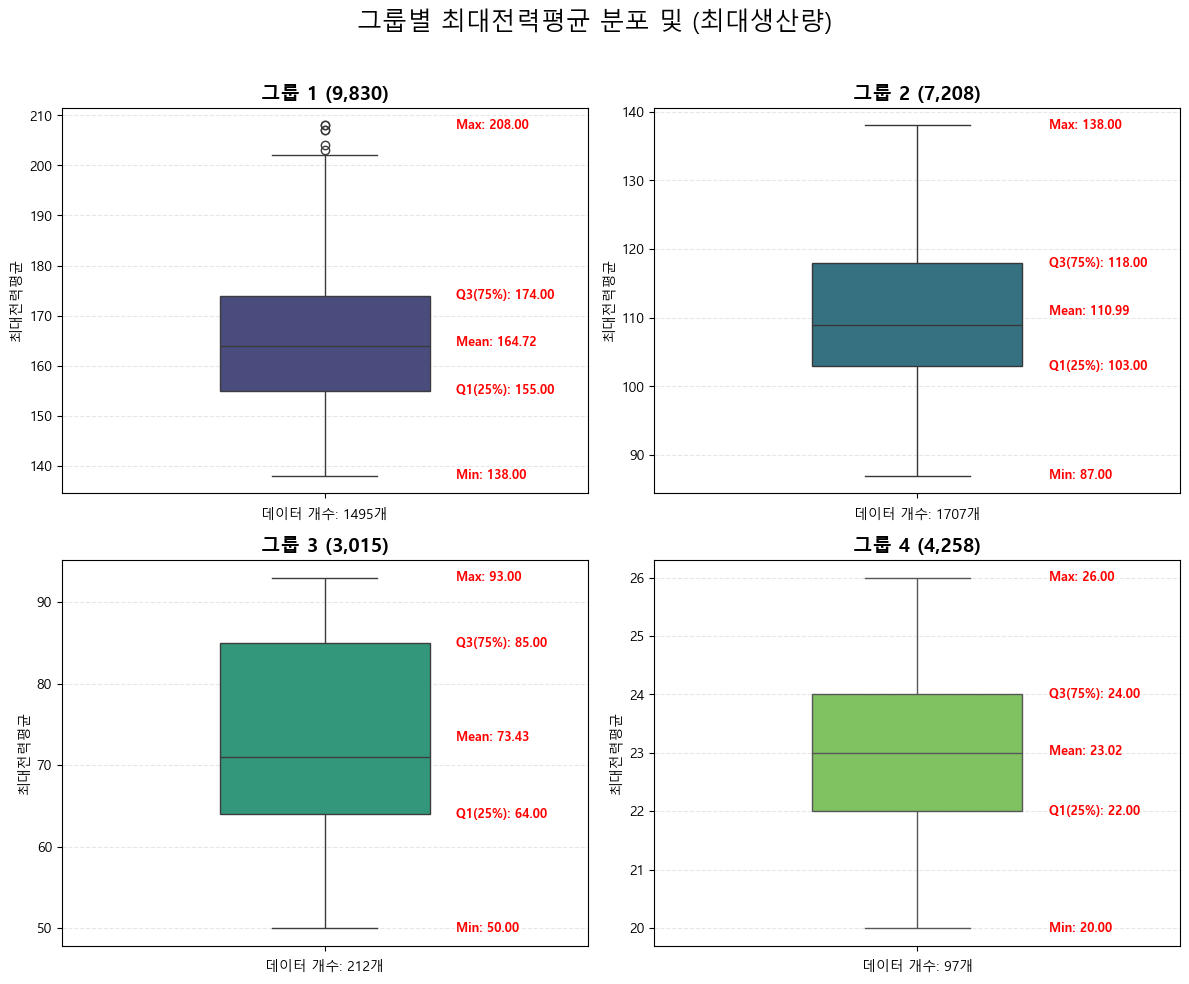

In [16]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 고유 그룹 개수 확인 및 레이아웃 설정
labels = sorted(df_target['생산구분'].unique())
n_groups = len(labels)
n_cols = 2  
n_rows = math.ceil(n_groups / n_cols)

# 2. 피규어 생성
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4.8))
axes = axes.flatten()

# 각 생산구분별로 순회하며 시각화
for i, label in enumerate(labels):
    group_data = df_target[df_target['생산구분'] == label]
    
    # 통계값 계산
    stats = group_data['최대전력평균'].describe()
    mean_val = group_data['최대전력평균'].mean()
    q1, q3 = stats['25%'], stats['75%']
    min_val, max_val = stats['min'], stats['max'] # 최솟값, 최댓값 추가
    max_prod = group_data['생산량'].max()

    # 박스플롯 그리기
    sns.boxplot(
        data=group_data,
        y='최대전력평균',
        ax=axes[i],
        color=sns.color_palette("viridis", n_groups)[i],
        width=0.4
    )

    # 텍스트 추가 (오른쪽 지점)
    text_x_pos = 0.25 
    font_style = {'fontsize': 9, 'color': 'red', 'fontweight': 'bold'}
    
    # 상단부터 하단까지 순서대로 표시
    axes[i].text(text_x_pos, max_val, f'Max: {max_val:.2f}', va='center', **font_style)
    axes[i].text(text_x_pos, q3, f'Q3(75%): {q3:.2f}', va='center', **font_style)
    axes[i].text(text_x_pos, mean_val, f'Mean: {mean_val:.2f}', va='center', **font_style)
    axes[i].text(text_x_pos, q1, f'Q1(25%): {q1:.2f}', va='center', **font_style)
    axes[i].text(text_x_pos, min_val, f'Min: {min_val:.2f}', va='center', **font_style)

    # 타이틀 및 라벨 설정
    axes[i].set_title(f'그룹 {int(label)} ({max_prod:,.0f})', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('최대전력평균')
    axes[i].set_xlabel(f'데이터 개수: {len(group_data)}개')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

# 3. 빈 서브플롯 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('그룹별 최대전력평균 분포 및 (최대생산량)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()



## 3.3 생산량, 인건비, 최대전력 상관관계 분석 결과
- 생산량-인건비 비율로 분류 시 3개로 구분 : 다만 인접한 두개의 구분이 모호함
    - 생산량이 적은 영역에서의 구분이 더욱 모호해짐 => 별도 추가 작업 필요
- 최대전력을 추가하여 분류시 두개의 모호한 그룹이 3개의 그룹으로 뚜렷하게 구분됨
    - 전력량이 추가되면서 경계가 확실해짐

## 각 그룹별 사용전력량 구하기
- 기본 사용량 + 생산량에 따른 증가치 (단, 최대값은 3/4 값의 90%)
- 기본 사용량 : 1/4 값의 70% 
- 생산량에 따른 증가치 = 생산량/최대생산량 * (최대사용량-기본사용량)
- 기본전력량 + (최대전력량-기본전력량) * 생산량/최대생산량
- 위 값이 최대전력평균의 90% 이상이면 최대전력평균의 90%로 적용
* 단, 4 그룹은 최대전력평균의 70% 로 고정하되 15를 하한으로 함

## 3.4 비생산 시 최대전력 분포 분석

최빈값:
 0    23
Name: 최대전력평균, dtype: int64


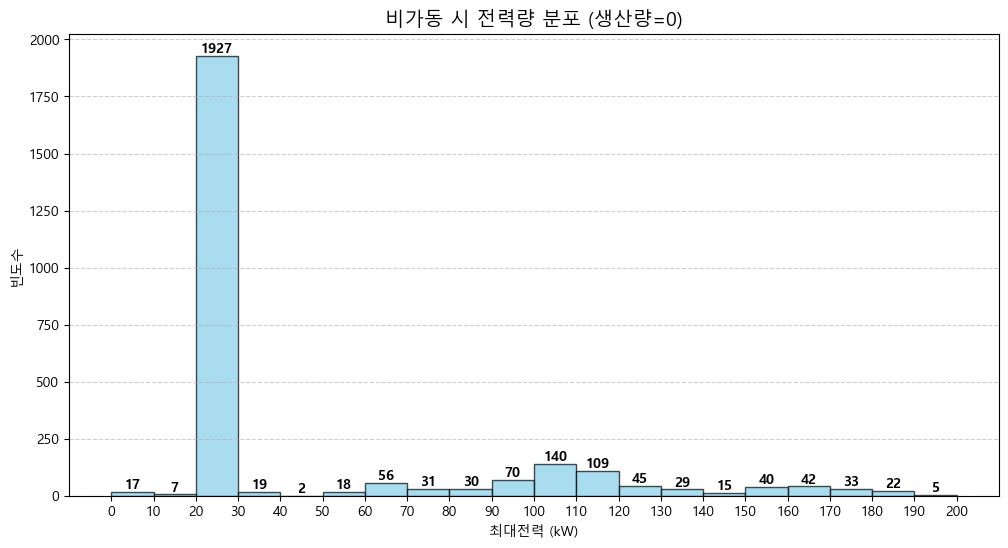

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 추출 및 최빈값 확인
df_zero = power_df[power_df['생산량'] == 0]['최대전력평균']
print("최빈값:\n", df_zero.mode())

# 2. 히스토그램 설정
custom_bins = np.arange(0, 201, 10)

plt.figure(figsize=(12, 6))

# plt.hist는 n(빈도수), bins(경계값), patches(그래프 객체)를 반환합니다.
n, bins, patches = plt.hist(df_zero, bins=custom_bins, color='skyblue', edgecolor='black', alpha=0.7)

# 3. 각 막대(patch) 위에 빈도수 표시
for i in range(len(n)):
    # 빈도수가 0보다 큰 경우에만 표시 (그래프가 깔끔해짐)
    if n[i] > 0:
        # x 좌표: 막대의 중간 지점, y 좌표: 막대의 높이(빈도수)
        plt.text(bins[i] + 5, n[i] + 0.5, int(n[i]), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("비가동 시 전력량 분포 (생산량=0)", fontsize=14)
plt.xlabel("최대전력 (kW)")
plt.ylabel("빈도수")
plt.xticks(custom_bins) # x축 눈금을 bins 간격과 맞춤
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


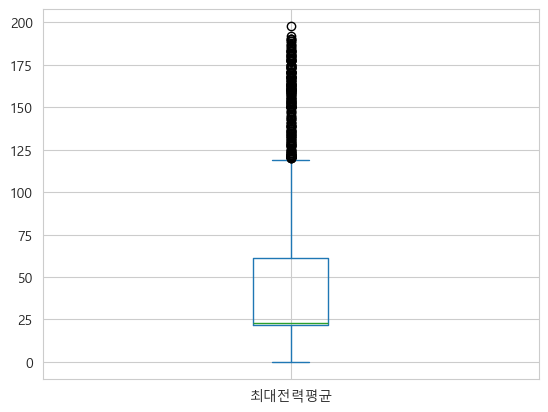

In [103]:
# 생산량이 0 인 경우의 최대전력량 분포
df = power_df[power_df['생산량']==0]['최대전력평균']
df.plot(kind='box')
plt.show()

## 3.5 비생산 시 사용전략량 산정
- 최대전력평균 * 70% ~ 60% (40kwh 기준)
- 최소 : 15KWh, 최대 150kWh로 제한

비가동 시 전체 최대전력평균 전력량: 46.19 kW


C:\Users\Admin\AppData\Local\Temp\ipykernel_12476\1432717635.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")


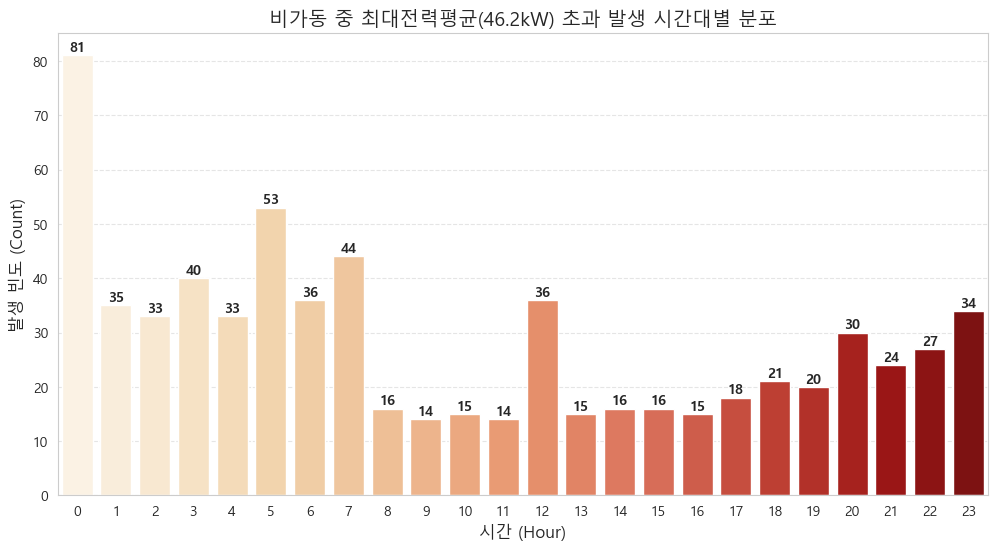

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 생산량이 0인 데이터만 추출
df_zero = power_df[power_df['생산량'] == 0].copy()

# 2. 비가동 시 전력량의 전체 최대전력평균 계산 (기준값)
zero_power_mean = df_zero['최대전력평균'].mean()
print(f"비가동 시 전체 최대전력평균 전력량: {zero_power_mean:.2f} kW")

# 3. 최대전력평균을 초과하는 '이상 전력' 데이터만 필터링
# (최대전력평균을 넘어서는 경우의 '빈도'를 보고 싶다면 count, '총량'을 보고 싶다면 sum 사용)
df_over_mean = df_zero[df_zero['최대전력평균'] > zero_power_mean]

# 4. 시간대(0~23)별로 그룹화하여 빈도수(횟수) 계산
hourly_dist = df_over_mean.groupby('시간')['최대전력평균'].count().reindex(range(24), fill_value=0)

# --- 시각화 ---
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")

# 각 막대 위에 수치 표시
for i, v in enumerate(hourly_dist.values):
    if v > 0:
        plt.text(i, v + 0.2, int(v), ha='center', va='bottom', fontweight='bold')

plt.title(f"비가동 중 최대전력평균({zero_power_mean:.1f}kW) 초과 발생 시간대별 분포", fontsize=14)
plt.xlabel("시간 (Hour)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


기준값: 34.59446744448626


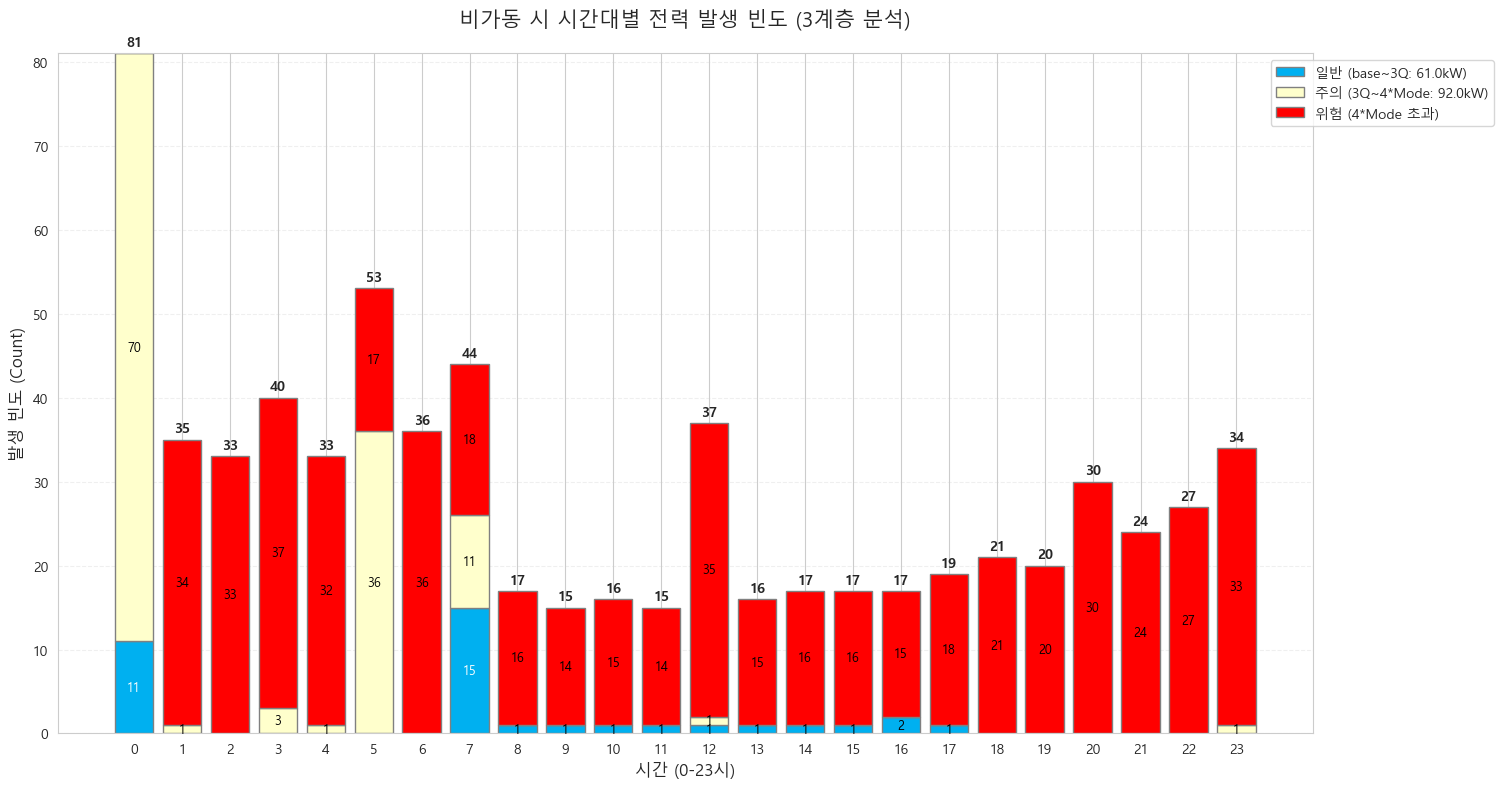

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 필터링 및 기준값 계산
df_zero = power_df[power_df['생산량'] == 0].copy()

mode_val = df_zero['최대전력평균'].mode()[0]
mean_val = df_zero['최대전력평균'].mean()
base_val = (mode_val + mean_val) / 2
print("기준값:", base_val)
q3_val = df_zero['최대전력평균'].quantile(0.75)
high_val = 4 * mode_val

# 2. 3계층 빈도 계산 (구간 설정)
dist_under = df_zero[(df_zero['최대전력평균'] > base_val) & (df_zero['최대전력평균'] <= q3_val)].groupby('시간')['최대전력평균'].count().reindex(range(24), fill_value=0)
dist_middle = df_zero[(df_zero['최대전력평균'] > q3_val) & (df_zero['최대전력평균'] <= high_val)].groupby('시간')['최대전력평균'].count().reindex(range(24), fill_value=0)
dist_over = df_zero[df_zero['최대전력평균'] > high_val].groupby('시간')['최대전력평균'].count().reindex(range(24), fill_value=0)

# 3. 누적 막대 그래프 시각화
plt.figure(figsize=(15, 8))

# 계층 1: 아래쪽 (파란색)
plt.bar(range(24), dist_under, color='#00B0F0', label=f'일반 (base~3Q: {q3_val:.1f}kW)', edgecolor='grey')

# 계층 2: 중간 (노란색) - bottom에 dist_under 적용
plt.bar(range(24), dist_middle, bottom=dist_under, color='#FFFFCC', label=f'주의 (3Q~4*Mode: {high_val:.1f}kW)', edgecolor='grey')

# 계층 3: 위쪽 (빨간색) - bottom에 (dist_under + dist_middle) 적용
plt.bar(range(24), dist_over, bottom=dist_under + dist_middle, color='#FF0000', label=f'위험 (4*Mode 초과)', edgecolor='grey')

# 4. 수치 표시 로직 수정
for i in range(24):
    u = dist_under[i]
    m = dist_middle[i]
    o = dist_over[i]
    total = u + m + o
    
    if total > 0:
        # 맨 위 전체 합계
        plt.text(i, total + 0.5, int(total), ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # 빨간색 구간 중앙 (High)
        if o > 0:
            plt.text(i, u + m + o/2, int(o), ha='center', va='center', color='black', fontsize=9)
            
        # 노란색 구간 중앙 (Middle)
        if m > 0:
            plt.text(i, u + m/2, int(m), ha='center', va='center', color='black', fontsize=9)
            
        # 파란색 구간 중앙 (Under)
        if u > 0:
            plt.text(i, u/2, int(u), ha='center', va='center', color='white' if u > 10 else 'black', fontsize=9)

plt.title(f"비가동 시 시간대별 전력 발생 빈도 (3계층 분석)", fontsize=15, pad=20)
plt.xlabel("시간 (0-23시)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




# 4. 전력량 - 추정값

## 4.1 추정 로직 요약

### 생산 그룹별 사용전력량 구하기
- 사용전력량 = 기본 사용량 + 생산량에 따른 증가치
- 기본 사용량 : 해당 그룹의 '최대전력량평균' Q1/4 값의 70% 
- 생산량에 따른 증가치 = 생산량/최대생산량 * (최대사용한계량-기본사용량)
   - 최대사용한계량 = '최대전력량평균' 통계량인 Q3/4 값의 90%
- 기본전력량 + (최대전력사용량-기본전력량) * 생산량/최대생산량
- 위 값이 최대전력평균의 90% 이상이면 최대전력평균의 90%로 적용

### 비생산 시 사용전력량 산정
- 최대전력평균 * 60 ~ 70%  (40khw 이상인 경우 60%, 그 이하는 70%)
- 최소 : 15KWh, 최대 150kWh로 제한 (양쪽 초과시 최소/최대 허용값으로 설정)

In [18]:
import numpy as np

# 1. 생산 그룹별(생산구분 > 0) 통계량 미리 계산
# 그룹별 Q1(25%), Q3(75%), 최대생산량을 딕셔너리로 저장
stats = power_df[power_df['생산구분'] > 0].groupby('생산구분').agg({
    '최대전력평균': [lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
    '생산량': 'max'
})
stats.columns = ['Q1', 'Q3', 'MaxProd']

def calculate_estimated_power(row):
    # [Case 1] 비생산 시 (생산구분 == 0)
    if row['생산구분'] == 0:
        if row['최대전력평균'] < 40 :
            val = row['최대전력평균'] * 0.7
        else :
            val = 28 + (row['최대전력평균'] - 40) * 0.6
        return np.clip(val, 15.0, 150.0) # 최소 15, 최대 150 제한
    
    # [Case 2] 생산 시 (생산구분 == 4 )
    elif row['생산구분'] == 4 :
        val = row['최대전력평균'] * 0.7
        return max(15.0, val)
    # [Case 3] 생산 시 ( 0 < 생산구분 < 4 )
    else :
        group_stat = stats.loc[row['생산구분']]
        
        # 기본 사용량 : Q1의 70%
        base_power = group_stat['Q1'] * 0.7
        
        # 최대사용한계량 : Q3의 90%
        limit_power = group_stat['Q3'] * 0.9
        
        # 생산량에 따른 증가치 계산
        # 공식: 기본전력량 + (최대사용한계량 - 기본전력량) * (현재생산량 / 최대생산량)
        ratio = row['생산량'] / group_stat['MaxProd'] if group_stat['MaxProd'] > 0 else 0
        est_val = base_power + (limit_power - base_power) * ratio
        
        # 상한선 적용: 최대전력평균의 90%를 초과할 수 없음
        max_allowable = row['최대전력평균'] * 0.9
        return min(est_val, max_allowable)

# 최종 컬럼 생성
power_df['추정사용전력량'] = power_df.apply(calculate_estimated_power, axis=1).round(2)

# 결과 확인 (샘플)
print(power_df[['생산구분', '생산량', '최대전력평균', '추정사용전력량']].head())


   생산구분  생산량  최대전력평균  추정사용전력량
0     0    0      61     40.6
1     0    0     105     67.0
2     0    0     104     66.4
3     0    0     105     67.0
4     0    0     107     68.2


In [20]:
stats_1 = {'op_code' : 1, 'mean' : 164.7, '1Q' : 155.0, '3Q' : 174.0, 'min' : 138.0, 'max' : 208.0, 'max_prod' : 9830}
stats_2 = {'op_code' : 2, 'mean' : 111.0, '1Q' : 103.0, '3Q' : 118.0, 'min' :  87.0, 'max' : 138.0, 'max_prod' : 7280}
stats_3 = {'op_code' : 3, 'mean' :  73.5, '1Q' :  64.2, '3Q' :  85.0, 'min' :  50.0, 'max' :  93.0, 'max_prod' : 4406}
stats_4 = {'op_code' : 4, 'mean' :  23.0, '1Q' :  22.0, '3Q' :  24.0, 'min' :  20.0, 'max' :  26.0, 'max_prod' : 4258}

# 리스트로 묶어서 데이터프레임 생성
df_stats = pd.DataFrame([stats_1, stats_2, stats_3, stats_4])
df_stats = df_stats.set_index(keys='op_code', drop = True)

df_stats

,mean,1Q,3Q,min,max,max_prod
op_code,,,,,,
1,164.7,155.0,174.0,138.0,208.0,9830
2,111.0,103.0,118.0,87.0,138.0,7280
3,73.5,64.2,85.0,50.0,93.0,4406
4,23.0,22.0,24.0,20.0,26.0,4258


In [27]:
import numpy as np

# 1. 생산 그룹별(생산구분 > 0) 통계량 미리 계산
# 그룹별 Q1(25%), Q3(75%), 최대생산량을 딕셔너리로 저장

stats_1 = {'op_code' : 1, 'mean' : 164.7, '1Q' : 155.0, '3Q' : 174.0, 'min' : 138.0, 'max' : 208.0, 'max_prod' : 9830}
stats_2 = {'op_code' : 2, 'mean' : 111.0, '1Q' : 103.0, '3Q' : 118.0, 'min' :  87.0, 'max' : 138.0, 'max_prod' : 7280}
stats_3 = {'op_code' : 3, 'mean' :  73.5, '1Q' :  64.2, '3Q' :  85.0, 'min' :  50.0, 'max' :  93.0, 'max_prod' : 4406}
stats_4 = {'op_code' : 4, 'mean' :  23.0, '1Q' :  22.0, '3Q' :  24.0, 'min' :  20.0, 'max' :  26.0, 'max_prod' : 4258}

# 리스트로 묶어서 데이터프레임 생성
df_stats = pd.DataFrame([stats_1, stats_2, stats_3, stats_4]).set_index(keys='op_code', drop = True)

IDLE_UPPER_POWER = 50.0
IDLE_MAX_POWER = 150.0
IDLE_MIN_POWER = 15.0

# stats = power_df[power_df['생산구분'] > 0].groupby('생산구분').agg({
#     '최대전력평균': [lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
#     '생산량': 'max'
# })
# stats.columns = ['Q1', 'Q3', 'MaxProd']

def calculate_estimated_power(row):
    # [Case 1] 비생산 시 (생산구분 == 0)
    if row['생산구분'] == 0:
        if row['최대전력평균'] < IDLE_UPPER_POWER :
            val = row['최대전력평균'] * 0.7
        else :
            val = IDLE_UPPER_POWER * 0.7 + (row['최대전력평균'] - IDLE_UPPER_POWER) * 0.6
        return np.clip(val, IDLE_MIN_POWER, IDLE_MAX_POWER) # 최소 15, 최대 150 제한
    
    # [Case 2] 생산 시 (생산구분 == 4 )
    elif row['생산구분'] == 4 :
        val = row['최대전력평균'] * 0.7
        return max(IDLE_MIN_POWER, val)
    # [Case 3] 생산 시 ( 0 < 생산구분 < 4 )
    else : # (생산구분 == 1, 2, 3 )
        
        group_stat = df_stats.loc[row['생산구분']]
        
        # 기본 사용량 : Q1의 70%
        base_power = group_stat['1Q'] * 0.7
        
        # 최대사용한계량 : Q3의 90%
        limit_power = group_stat['3Q'] * 0.9
        
        # 생산량에 따른 증가치 계산
        # 공식: 기본전력량 + (최대사용한계량 - 기본전력량) * (현재생산량 / 최대생산량)
        ratio = row['생산량'] / group_stat['max_prod'] if group_stat['max_prod'] > 0 else 0
        est_val = base_power + (limit_power - base_power) * ratio
        
        # 상한선 적용: 최대전력평균의 90%를 초과할 수 없음
        max_allowable = row['최대전력평균'] * 0.9
        return min(est_val, max_allowable)

# 최종 컬럼 생성
power_df['추정사용전력량'] = power_df.apply(calculate_estimated_power, axis=1).round(2)

# 결과 확인 (샘플)
print(power_df[['생산구분', '생산량', '최대전력평균', '추정사용전력량']].head())

   생산구분  생산량  최대전력평균  추정사용전력량
0     0    0      61     41.6
1     0    0     105     68.0
2     0    0     104     67.4
3     0    0     105     68.0
4     0    0     107     69.2


In [40]:
power_df[['생산량', '생산구분', '최대전력평균', '추정사용전력량']]

,생산량,생산구분,최대전력평균,추정사용전력량
0,0,0,61,41.60
1,0,0,105,68.00
2,0,0,104,67.40
3,0,0,105,68.00
4,0,0,107,69.20
...,...,...,...,...
6163,1497,1,153,115.83
6164,45,1,128,108.72
6165,149,1,128,109.23
6166,66,1,111,99.90


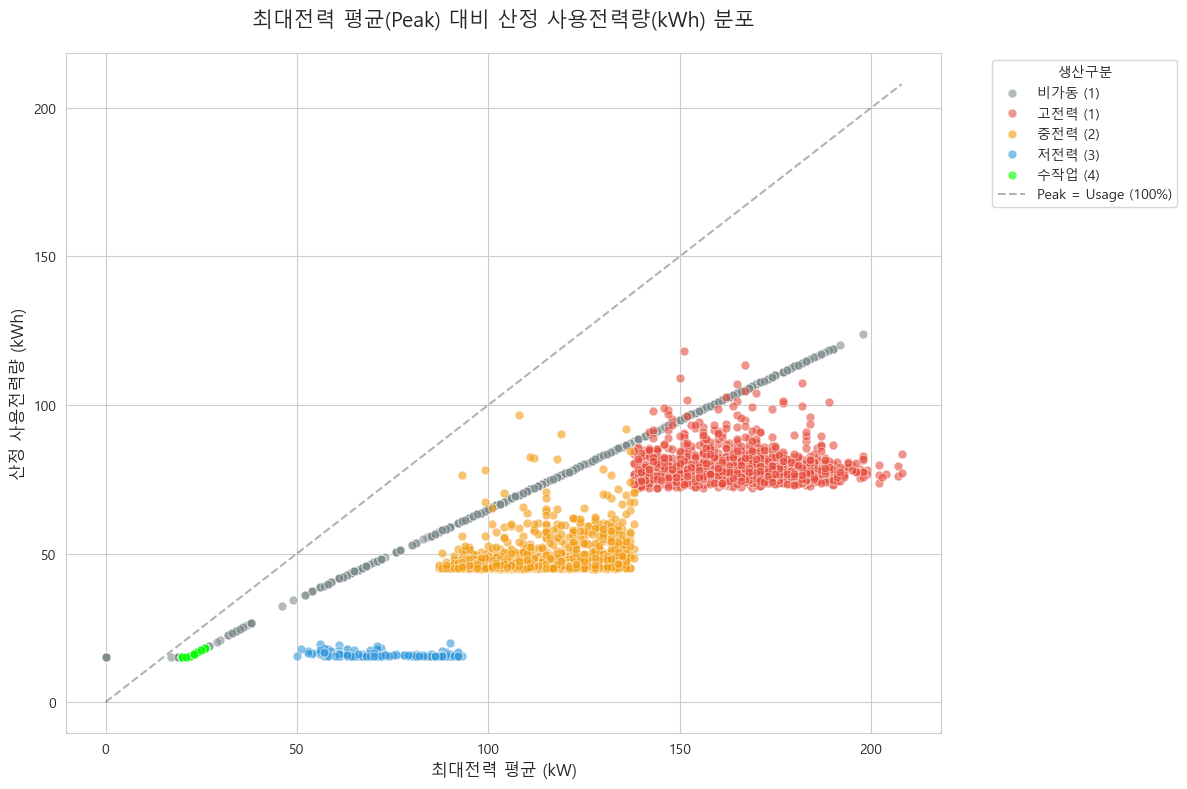

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 설정
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 2. 생산구분별 색상 및 라벨 지정
# -1: 비가동(Gray), 1: 고전력(Red), 2: 중전력(Orange), 4: 저전력(Blue)
palette = {0: '#7F8C8D', 1: '#E74C3C', 2: '#F39C12', 3: '#3498DB', 4: '#00FF00'}
labels = {0: '비가동 (1)', 1: '고전력 (1)', 2: '중전력 (2)', 3: '저전력 (3)', 4: '수작업 (4)'}

# 3. 그룹별 산점도 그리기
for cat in sorted(power_df['생산구분'].unique()):
    subset = power_df[power_df['생산구분'] == cat]
    plt.scatter(
        subset['최대전력평균'], 
        subset['추정사용전력량'],
        label=labels.get(cat, f'Group {cat}'),
        color=palette.get(cat, 'black'),
        alpha=0.6, 
        s=40, 
        edgecolor='w',
        linewidth=0.5
    )

# 4. 가이드라인 추가 (y=x 선: 피크가 곧 사용량인 100% 지점)
max_val = max(power_df['최대전력평균'].max(), power_df['추정사용전력량'].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Peak = Usage (100%)')

# 5. 그래프 디테일
plt.title('최대전력 평균(Peak) 대비 산정 사용전력량(kWh) 분포', fontsize=15, pad=20)
plt.xlabel('최대전력 평균 (kW)', fontsize=12)
plt.ylabel('산정 사용전력량 (kWh)', fontsize=12)
plt.legend(title='생산구분', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [32]:
power_df

,날짜,시간,15분,30분,45분,60분,최대전력평균,생산량,기온,풍속,습도,강수량,전기요금(계절),요일,일자,월,공장인원,인건비할증,생산구분,추정사용전력량
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5,0,40.60
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5,0,67.00
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5,0,66.40
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5,0,67.00
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5,0,68.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5,1,115.83
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5,2,72.31
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5,2,72.80
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5,2,72.41


# 4. CSV 로 다운받기

In [31]:
from pathlib import Path

# 1. 경로 설정 및 폴더 생성
save_dir = Path('./data')
save_dir.mkdir(parents=True, exist_ok=True)

# 2. 파일 저장
save_path = save_dir / 'power_estimate.csv'
power_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"저장 완료: {save_path.absolute()}")


저장 완료: d:\Project\PowerUsage\data\power_estimate.csv
